# After running ppfx with the EMILES library on the MUSE cube of the central 30 arcseconds here we inspect the results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits


In [1]:
results_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.npz'
results_fits_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits'


In [3]:
results_fits = fits.open(results_fits_path)

# Saved data structure

It has a set of HDUs, the first one is the BINTABLE which has the information about the power binning.  Then it has ImageHDUs containing the maps

In [4]:
results_fits.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1  BIN_RESULTS    1 BinTableHDU     39   2180R x 15C   [J, D, D, D, D, D, D, D, D, D, D, D, J, D, D]   
  2  SPAXELS       1 BinTableHDU     35   90000R x 13C   [J, J, D, D, D, D, J, D, D, D, D, D, D]   
  3  BIN_MAP       1 ImageHDU         8   (300, 300)   int32   
  4  VEL_MAP       1 ImageHDU         8   (300, 300)   float32   
  5  SIGMA_MAP     1 ImageHDU         8   (300, 300)   float32   
  6  VELERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  7  SIGERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  8  LOGAGE_MAP    1 ImageHDU         8   (300, 300)   float32   
  9  METAL_MAP     1 ImageHDU         8   (300, 300)   float32   
 10  SIGNAL_MAP    1 ImageHDU         8   (300, 30

# Plot the maps

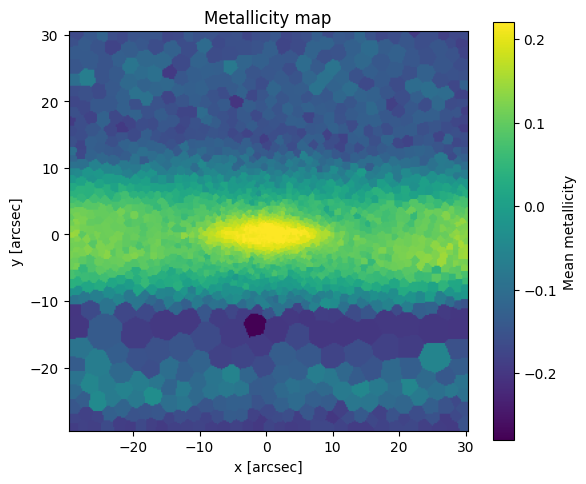

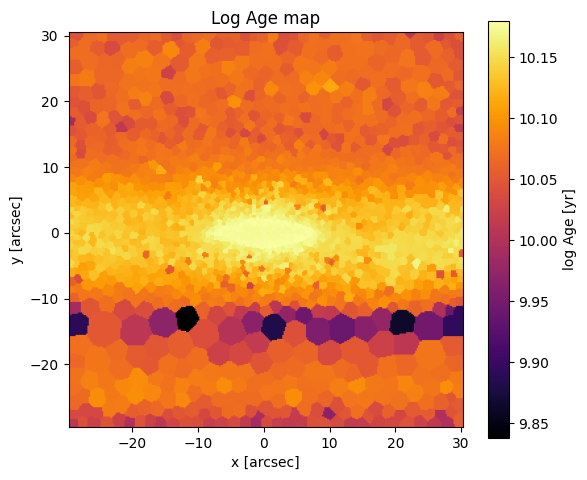

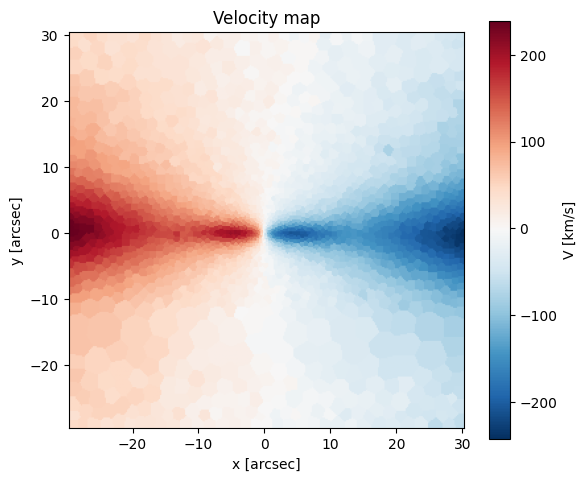

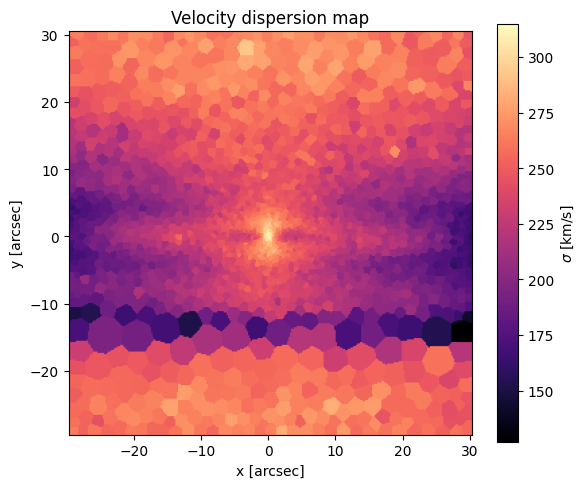

In [5]:

# Read the saved maps
metal_map = results_fits["METAL_MAP"].data
logage_map = results_fits["LOGAGE_MAP"].data
vel_map = results_fits["VEL_MAP"].data
sigma_map = results_fits["SIGMA_MAP"].data

# Get x/y coordinates from the SPAXELS table so the axes are in arcsec
spax = results_fits["SPAXELS"].data
x = spax["X_ARCSEC"]
y = spax["Y_ARCSEC"]

# Estimate image extent from the spaxel coordinates
x_unique = np.unique(np.round(x, 6))
y_unique = np.unique(np.round(y, 6))

dx = np.median(np.diff(x_unique)) if len(x_unique) > 1 else 1.0
dy = np.median(np.diff(y_unique)) if len(y_unique) > 1 else 1.0

extent = [
    x_unique.min() - dx/2, x_unique.max() + dx/2,
    y_unique.min() - dy/2, y_unique.max() + dy/2
]

def plot_map(data, title, cbar_label, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        aspect="equal",
        cmap=cmap
    )
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_xlabel("x [arcsec]")
    ax.set_ylabel("y [arcsec]")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_map(metal_map, "Metallicity map", "Mean metallicity", cmap="viridis")
plot_map(logage_map, "Log Age map", "log Age [yr]", cmap="inferno")
plot_map(vel_map, "Velocity map", "V [km/s]", cmap="RdBu_r")
plot_map(sigma_map, "Velocity dispersion map", r"$\sigma$ [km/s]", cmap="magma")

# Radial maps

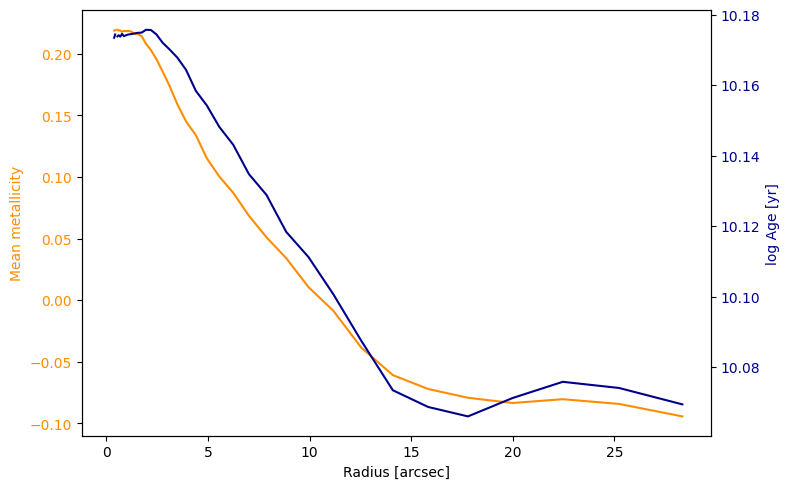

In [7]:
# lets take compute the radial metallicity and age profiles by averaging in annuli
r = np.sqrt(x**2 + y**2) # this is the flattened radius in arcsec
# make it 2D for use in masking the maps
r = r.reshape(metal_map.shape)  # reshape to match the map dimensions

#r_bins = np.arange(0, 29, 1)  # 1 arcsec bins up to 30 arcsec
# make logspaced bins with a higher resolution in the center
r_bins = np.logspace(np.log10(0.1), np.log10(30), num=50)  # 15 bins from 0.5 to 30 arcsec
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
metal_radial_profile = np.zeros_like(r_bin_centers)
logage_radial_profile = np.zeros_like(r_bin_centers)

for i in range(len(r_bins) - 1):
    in_bin = (r >= r_bins[i]) & (r < r_bins[i+1])
    if np.sum(in_bin) > 0:
        avg_mg= np.nanmean(metal_map[in_bin])
        metal_radial_profile[i] = avg_mg
        logage_radial_profile[i] = np.nanmean(logage_map[in_bin])
    else:
        metal_radial_profile[i] = np.nan
        logage_radial_profile[i] = np.nan
# Plot the radial profiles
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(r_bin_centers, metal_radial_profile, label="Metallicity", color="darkorange")
ax1.set_xlabel("Radius [arcsec]")
ax1.set_ylabel("Mean metallicity", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax2 = ax1.twinx()
ax2.plot(r_bin_centers, logage_radial_profile, label="Log Age", color="darkblue")
ax2.set_ylabel("log Age [yr]", color="darkblue")
ax2.tick_params(axis="y", labelcolor="darkblue")
fig.tight_layout()
plt.savefig('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/img_to_invert/metal_logage_radial_profile.png')
plt.show()

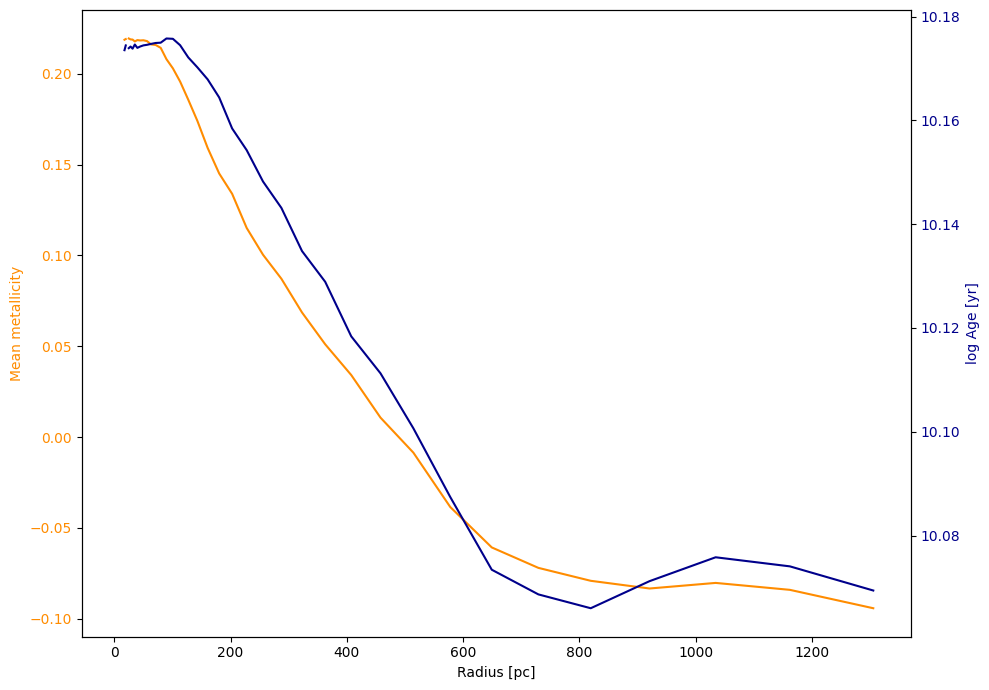

In [8]:
# make the same plot but with radius in pc using a distance of 9.5 Mpc (1 arcsec = 46 pc)
dist = 9.5e6  # distance in parsecs
arcsec_to_pc = dist * np.tan(np.radians(1/3600))
r_bin_centers_pc = r_bin_centers * arcsec_to_pc
fig, ax1 = plt.subplots(figsize=(10, 7))
ax1.plot(r_bin_centers_pc, metal_radial_profile, label="Metallicity", color="darkorange")
ax1.set_xlabel("Radius [pc]")
ax1.set_ylabel("Mean metallicity", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax2 = ax1.twinx()
ax2.plot(r_bin_centers_pc, logage_radial_profile, label="Log Age", color="darkblue")
ax2.set_ylabel("log Age [yr]", color="darkblue")
ax2.tick_params(axis="y", labelcolor="darkblue")
fig.tight_layout()
plt.savefig('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/img_to_invert/metal_logage_radial_profile_pc.png')
plt.show()

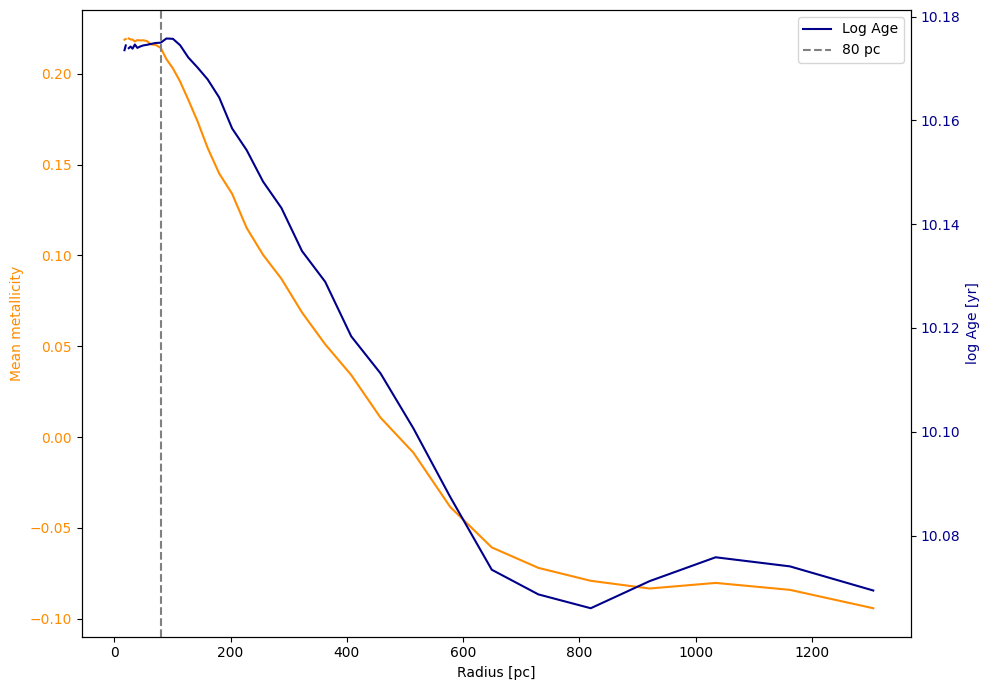

In [12]:
# make the same plot but with radius in pc using a distance of 9.5 Mpc (1 arcsec = 46 pc)
dist = 9.5e6  # distance in parsecs
arcsec_to_pc = dist * np.tan(np.radians(1/3600))
r_bin_centers_pc = r_bin_centers * arcsec_to_pc
fig, ax1 = plt.subplots(figsize=(10, 7))
ax1.plot(r_bin_centers_pc, metal_radial_profile, label="Metallicity", color="darkorange")
ax1.set_xlabel("Radius [pc]")
ax1.set_ylabel("Mean metallicity", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax2 = ax1.twinx()
ax2.plot(r_bin_centers_pc, logage_radial_profile, label="Log Age", color="darkblue")
ax2.set_ylabel("log Age [yr]", color="darkblue")
ax2.tick_params(axis="y", labelcolor="darkblue")
fig.tight_layout()
# add a vectical line at 100 pc to indicate the scale of the inner region
plt.axvline(80, color="gray", linestyle="--", label="80 pc")
plt.legend(loc="upper right")
plt.savefig('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/img_to_invert/metal_logage_radial_profile_pc_marked.png')
plt.show()

# Check anulii around the center

In [8]:
# compute the mean metallicity and age in the central 1 arcsec
central_mask = r < 5.0
central_metallicity = np.nanmean(metal_map[central_mask])
central_logage = np.nanmean(logage_map[central_mask])
print(f"Central metallicity (r < 5 arcsec): {central_metallicity:.3f}")
print(f"Central log age (r < 5 arcsec): {central_logage:.3f}")

Central metallicity (r < 5 arcsec): -0.248
Central log age (r < 5 arcsec): 9.530


In [9]:
# compute the mean metallicity and age in the outer 10-30 arcsec
outer_mask = (r >= 10.0) & (r < 30.0)
outer_metallicity = np.nanmean(metal_map[outer_mask])
outer_logage = np.nanmean(logage_map[outer_mask])
print(f"Outer metallicity (10 < r < 30 arcsec): {outer_metallicity:.3f}")
print(f"Outer log age (10 < r < 30 arcsec): {outer_logage:.3f}")


Outer metallicity (10 < r < 30 arcsec): -0.156
Outer log age (10 < r < 30 arcsec): 9.631


## PPXF for the central aperture and anulii fits

In [10]:
from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from powerbin import PowerBin
from plotbin.display_bins import display_bins

class read_data_cube:
    def __init__(self, filename, lam_range, redshift):
        """Read data cube, de-redshift, log rebin and compute coordinates of each spaxel."""

        self.read_fits_file(filename)

        # Only use the specified rest-frame wavelength range
        wave = self.wave/(1 + redshift)      # de-redshift the spectrum
        w = (wave > lam_range[0]) & (wave < lam_range[1])
        wave = wave[w]
        cube = self.cube[w, ...]
        cubevar = self.cubevar[w, ...]

        signal = np.nanmedian(cube, 0)
        noise = np.sqrt(np.nanmedian(cubevar, 0))

        # Create coordinates centred on the brightest spaxel
        jm = np.argmax(signal)
        row, col = map(np.ravel, np.indices(cube.shape[-2:]))
        x = (col - col[jm])*self.pixsize
        y = (row - row[jm])*self.pixsize

        # Transform cube into 2-dim array of spectra
        npix = cube.shape[0]
        spectra = cube.reshape(npix, -1)        # create array of spectra [npix, nx*ny]
        variance = cubevar.reshape(npix, -1)    # create array of variance [npix, nx*ny]

        c = 299792.458  # speed of light in km/s
        velscale = np.min(c*np.diff(np.log(wave)))  # Preserve smallest velocity step
        lam_range_temp = [np.min(wave), np.max(wave)]
        print(f"Velocity scale of the data: {velscale:.2f} km/s per pixel")
        spectra, ln_lam_gal, velscale = util.log_rebin(lam_range_temp, spectra, velscale=velscale)

        # Coordinates and spectra only for spaxels with enough signal
        self.spectra = spectra
        self.variance = variance
        self.x = x
        self.y = y
        self.signal = signal.ravel()
        self.noise = noise.ravel()

        self.col = col + 1   # start counting from 1
        self.row = row + 1
        self.velscale = velscale
        self.ln_lam_gal = ln_lam_gal
        self.fwhm_gal = self.fwhm_gal/(1 + redshift)

###############################################################################

    def read_fits_file(self, filename):
        """
        Read MUSE cube, noise, wavelength, spectral FWHM and pixel size.

        It must return the cube and cuberr as (npix, nx, ny) and wave as (npix,)

        IMPORTANT: This is not a general function! Its details depend on the
        way the data were stored in the FITS file and the available keywords in
        the FITS header. One may have to adapt the function to properly read
        the FITS file under analysis.
        """
        cube, head = fits.getdata(filename, header=True)

        # Only use the specified rest-frame wavelength range
        wave = head['CRVAL3'] + head['CD3_3']*np.arange(cube.shape[0])

        self.cube = cube
        self.cubevar = cube  # This file contains no uncertainties: assume Poissonian noise
        self.wave = wave
        self.fwhm_gal = 2.62  # Median FWHM = 2.62Å. Range: 2.51--2.88 (ESO instrument manual).
        self.pixsize = abs(head["CD1_1"])*3600    # 0.2"

In [11]:
# load the cube to get the wavelength array
cube_fits_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_cubes/c30_DATACUBE_normppxf_skycont_Part1_0000.fits'
lam_range_temp = [4750.0, 7409]   # Focus on optical region in MUSE
redshift = 0.003633               # redshift estimate from NED
sn_min = 0.0
cube_orig = read_data_cube(cube_fits_path, lam_range=lam_range_temp, redshift=redshift)


Velocity scale of the data: 50.41 km/s per pixel


In [14]:
# load the npz file to check the saved arrays
data_fits_an = np.load("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_results/anulii/ppxf_central_annulus_results.npz")

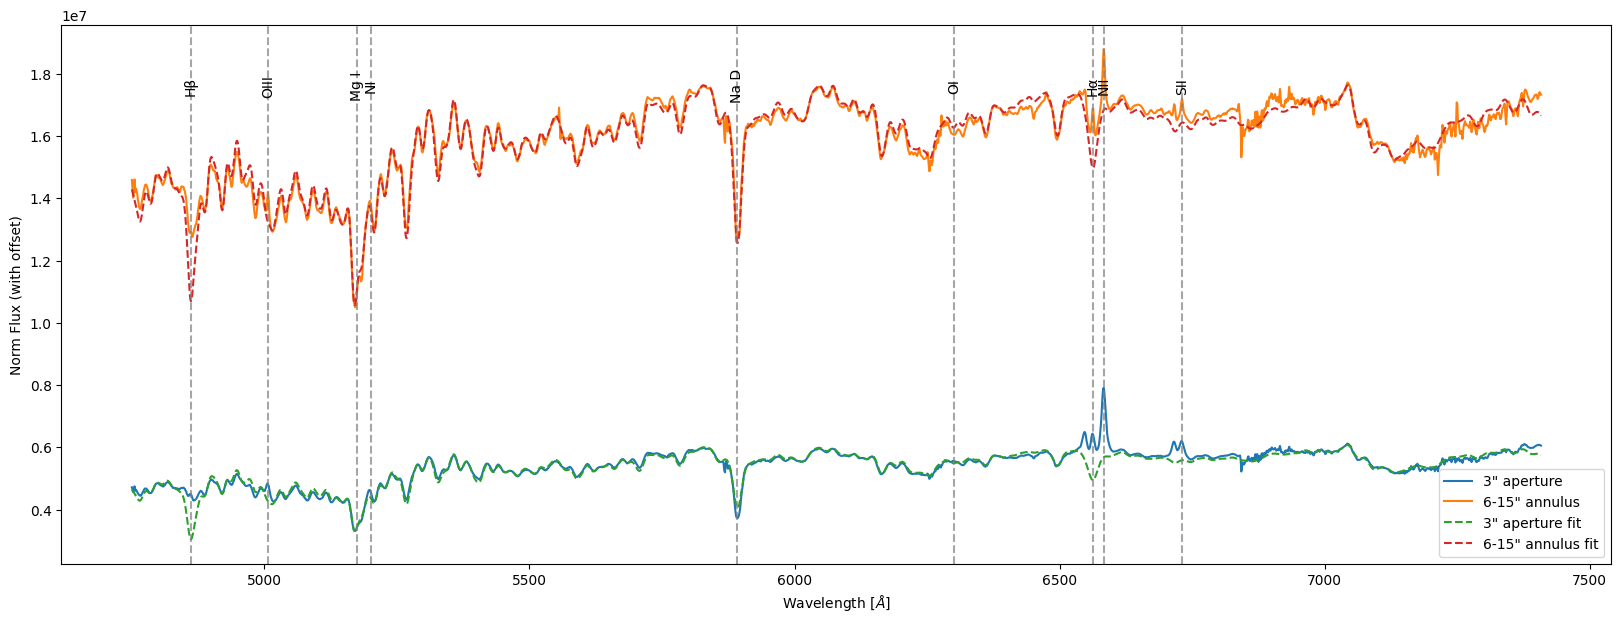

In [ ]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_spectra'], label = [r'3" aperture', r'6-15" annulus'])
# plot the best fit
ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_bestfit'], label = [r'3" aperture fit', r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Flux")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_c30_1/spectra_fit_comparison_2.pdf", bbox_inches='tight')
plt.show()


In [91]:
data_fits_an['binned_spectra'][:,0]

array([4722249.4855957 , 4674673.15506769, 4614277.10009766, ...,
       6081238.60310061, 6071976.65610741, 6059963.90541111],
      shape=(2644,))

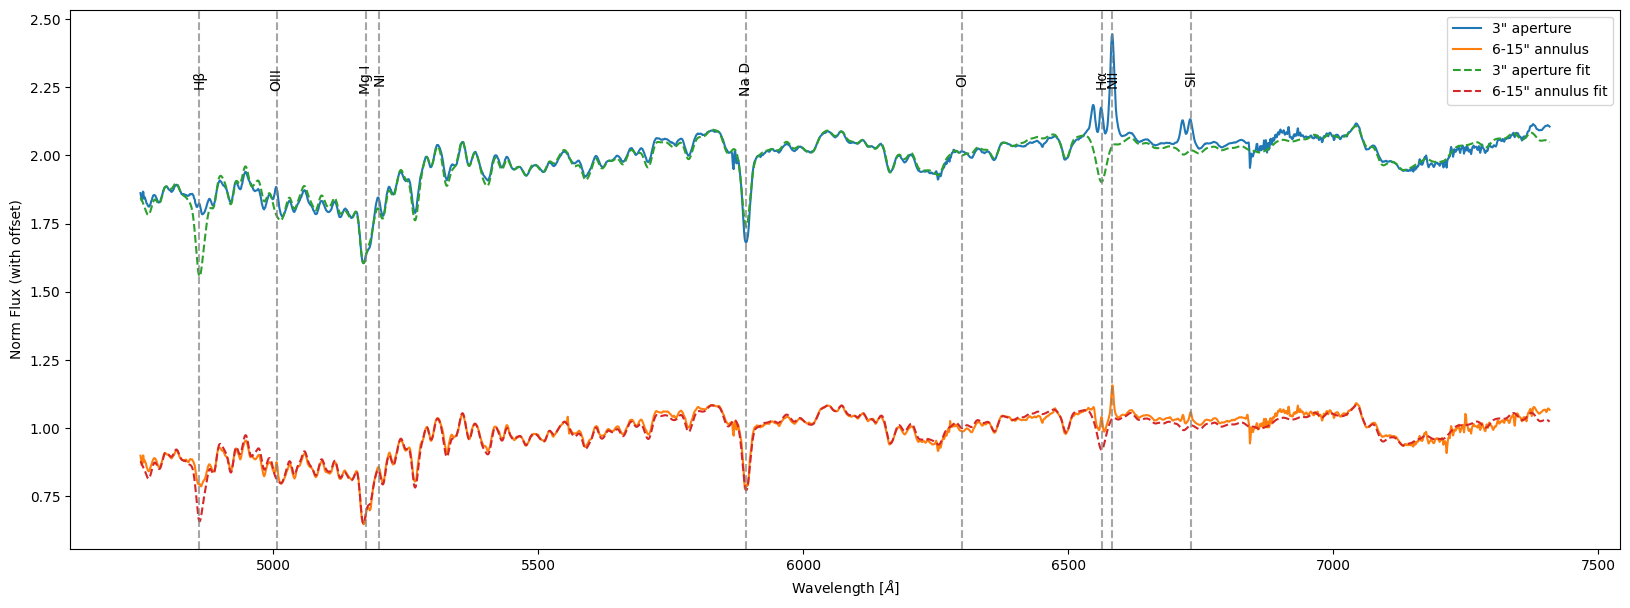

In [97]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_spectra'][:,0]/np.nanmedian(data_fits_an['binned_spectra'][:,0]) + 1,
          label = [r'3" aperture'])
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_spectra'][:,1]/np.nanmedian(data_fits_an['binned_spectra'][:,1]),
           label = [r'6-15" annulus'])

# plot the best fit
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_bestfit'][:,0]/np.nanmedian(data_fits_an['binned_bestfit'][:,0]) + 1,
          label = [r'3" aperture fit'], linestyle='--')
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_bestfit'][:,1]/np.nanmedian(data_fits_an['binned_bestfit'][:,1]),
           label = [r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Norm Flux (with offset)")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_c30_1/spectra_fit_comparison_norm.pdf", bbox_inches='tight')
plt.show()


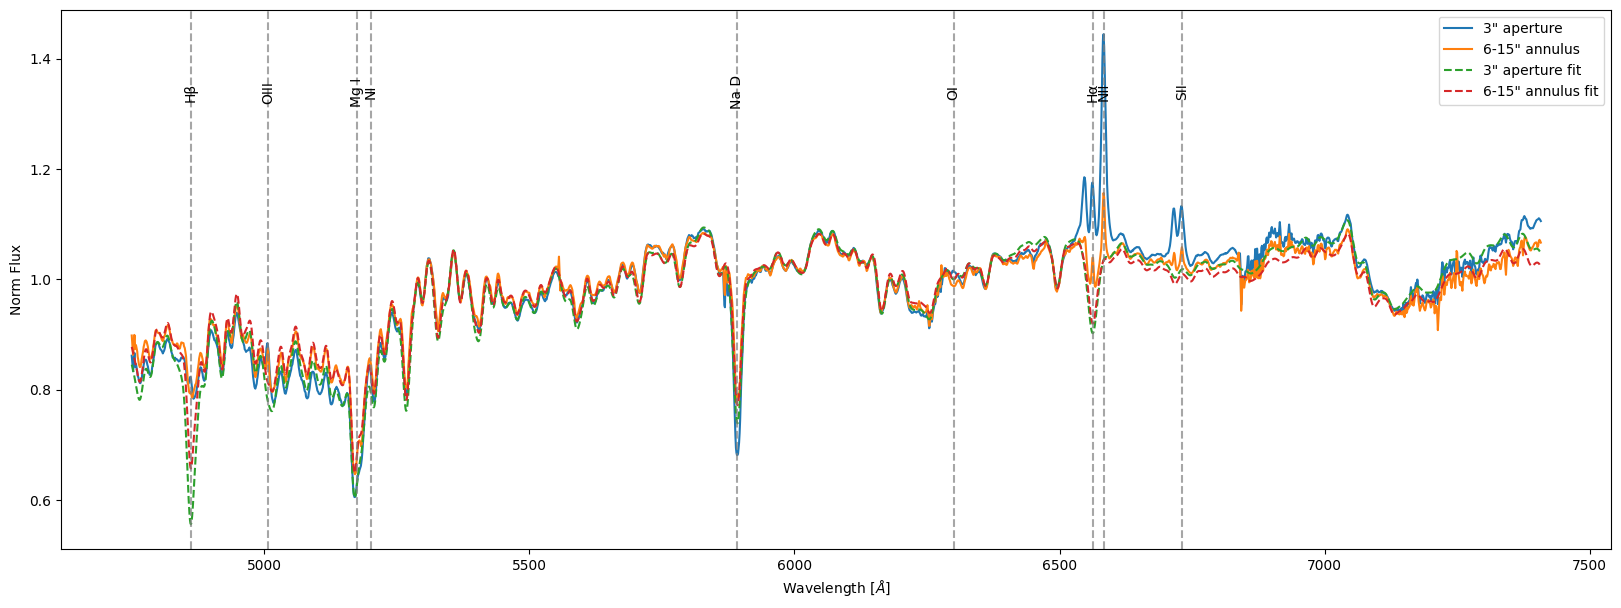

In [99]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_spectra'][:,0]/np.nanmedian(data_fits_an['binned_spectra'][:,0]),
          label = [r'3" aperture'])
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_spectra'][:,1]/np.nanmedian(data_fits_an['binned_spectra'][:,1]),
           label = [r'6-15" annulus'])

# plot the best fit
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_bestfit'][:,0]/np.nanmedian(data_fits_an['binned_bestfit'][:,0]),
          label = [r'3" aperture fit'], linestyle='--')
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_bestfit'][:,1]/np.nanmedian(data_fits_an['binned_bestfit'][:,1]),
           label = [r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Norm Flux")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_c30_1/spectra_fit_comparison_norm_ontop.pdf", bbox_inches='tight')
plt.show()


<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_62503/761078162.py:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_xlabel("Wavelength $[\AA]$")


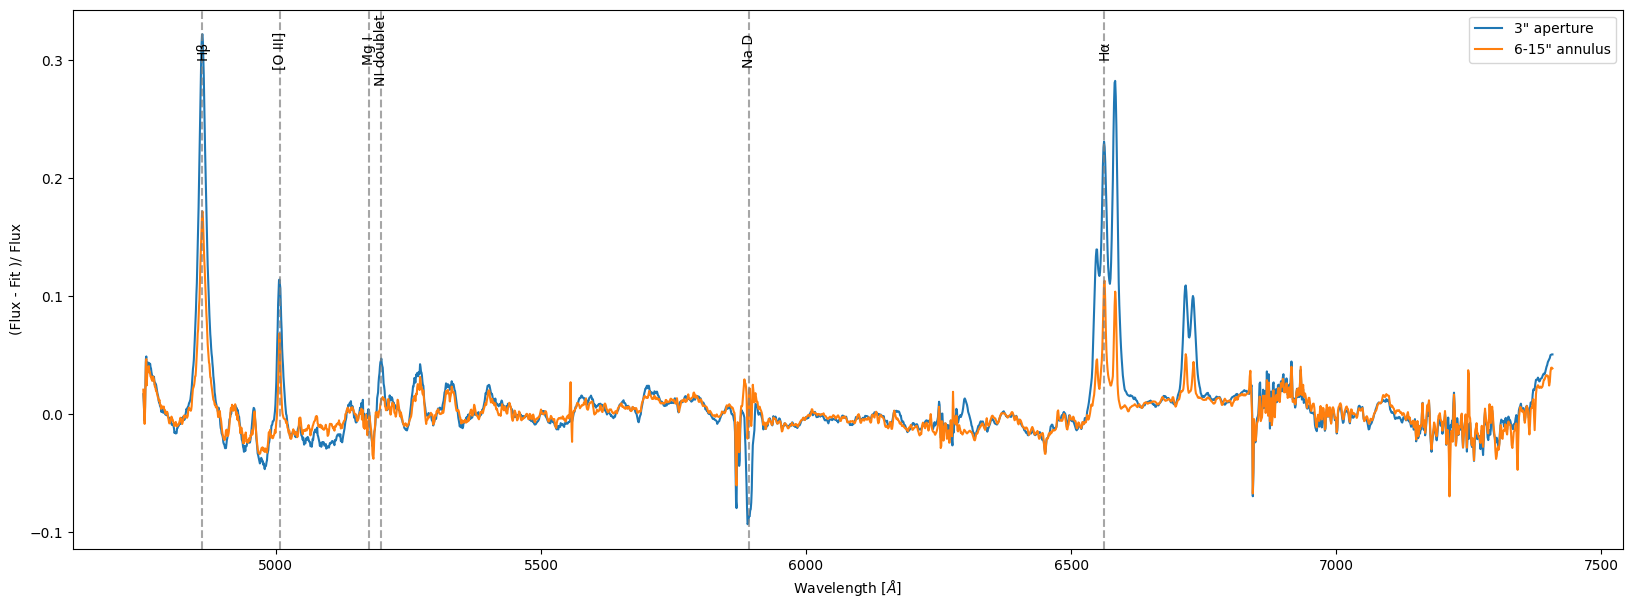

In [44]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], (data_fits_an['binned_spectra'] - data_fits_an['binned_bestfit'])/data_fits_an['binned_spectra'], label = [r'3" aperture', r'6-15" annulus'])
# plot the best fit
#ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_bestfit'], label = [r'3" aperture fit', r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
important_lines = {
    "Hβ": 4861.33,
    "[O III]": 5006.84,
    "Hα": 6562.79,
    #"[N II]": 6583.45,
    #"TiO": 6200.0,
    "Na D": 5892.0,
    "Mg I": 5175.0,
    "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel("Wavelength $[\AA]$")
ax.set_ylabel("(Flux - Fit )/ Flux")
ax.legend()
plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_c30_1/spectra_fit_residuals.pdf", bbox_inches='tight')
plt.show()
